In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
#look at the weather-only data dates
weather_path = "data/weather_data/merged_weather.csv"

df_weather = pd.read_csv(weather_path)
print(df_weather.columns)

print(f"{max(df_weather['time']), min(df_weather['time'])}")

Index(['time', 'latitude', 'longitude', 'ETo', 'RH', 'Rs', 'Tmax', 'Tmin',
       'pr', 'u2'],
      dtype='object')
('2024-03-20', '2020-01-01')


In [3]:
data_path = "data/merged_generation_weather.csv"

file_size = os.path.getsize(data_path)

print(f"Merged Generation/Weather Data File: {file_size/(1024**2):.3f} MB")

Merged Generation/Weather Data File: 125.898 MB


In [4]:
#Load Dataframe
df = pd.read_csv(data_path)
print(df.columns)

df = df.dropna()
print(df.shape)

Index(['ceg', 'latitude_x', 'longitude_x', 'date', 'gen_val(MW)',
       'subsys_name', 'state_name', 'plant_opn_mode', 'plant_type',
       'fuel_type', 'ons_id', 'wx_lat', 'wx_lon', 'wx_distance_deg', 'time',
       'latitude_y', 'longitude_y', 'ETo', 'RH', 'Rs', 'Tmax', 'Tmin', 'pr',
       'u2'],
      dtype='object')
(456642, 24)


In [5]:
#Look at the Date Range of the Data
df["date"] = pd.to_datetime(df["date"])
print(f"Start Date: {min(df["date"])} \t End Date: {max(df["date"])}")


Start Date: 2020-01-01 00:00:00 	 End Date: 2024-02-29 00:00:00


In [6]:
weather_feats = ["pr", "ETo", "Tmax", "Tmin", "u2", "RH", "Rs"]

numeric_df = df.select_dtypes(include=[float,int])
corr_mat = numeric_df.corr()
print(corr_mat["gen_val(MW)"])

latitude_x        -0.121480
longitude_x       -0.106204
gen_val(MW)        1.000000
wx_lat            -0.129720
wx_lon            -0.081315
wx_distance_deg    0.081450
latitude_y        -0.129720
longitude_y       -0.081315
ETo                0.002850
RH                 0.027734
Rs                 0.004719
Tmax              -0.042491
Tmin              -0.024900
pr                 0.003680
u2                 0.115180
Name: gen_val(MW), dtype: float64


In [7]:
df['plant_type'].value_counts()

plant_type
HIDROELÉTRICA    252678
TÉRMICA          175439
EOLIELÉTRICA      17835
FOTOVOLTAICA       5566
NUCLEAR            3042
T√âRMICA           2082
Name: count, dtype: int64

Correlation for Type: EOLIELÉTRICA: 
             gen_val(MW)    ETo     RH     Rs   Tmax   Tmin     pr     u2
gen_val(MW)        1.000  0.092 -0.035  0.088 -0.047 -0.005  0.038  0.147
ETo                0.092  1.000 -0.647  0.940  0.722  0.516 -0.247  0.069
RH                -0.035 -0.647  1.000 -0.667 -0.284 -0.046  0.359 -0.003
Rs                 0.088  0.940 -0.667  1.000  0.534  0.287 -0.278  0.033
Tmax              -0.047  0.722 -0.284  0.534  1.000  0.829 -0.172 -0.216
Tmin              -0.005  0.516 -0.046  0.287  0.829  1.000 -0.011 -0.158
pr                 0.038 -0.247  0.359 -0.278 -0.172 -0.011  1.000  0.083
u2                 0.147  0.069 -0.003  0.033 -0.216 -0.158  0.083  1.000
Correlation for Type: EOLIEL√âTRICA: 
             gen_val(MW)  ETo  RH  Rs  Tmax  Tmin  pr  u2
gen_val(MW)          1.0  NaN NaN NaN   NaN   NaN NaN NaN
ETo                  NaN  NaN NaN NaN   NaN   NaN NaN NaN
RH                   NaN  NaN NaN NaN   NaN   NaN NaN NaN
Rs                   NaN  N

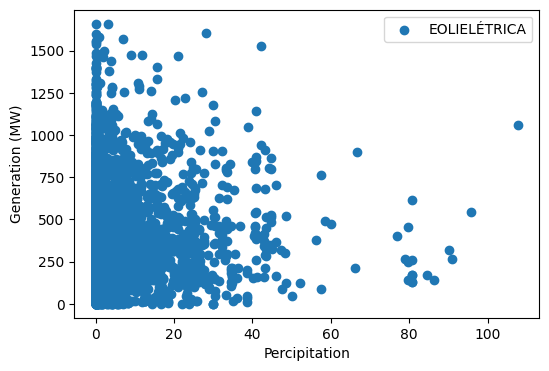

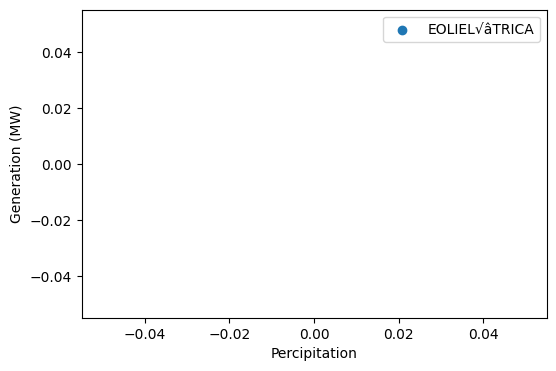

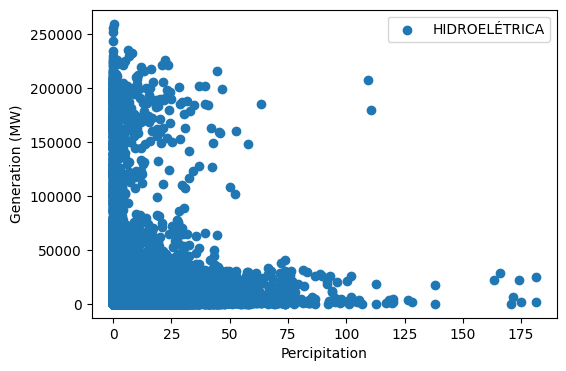

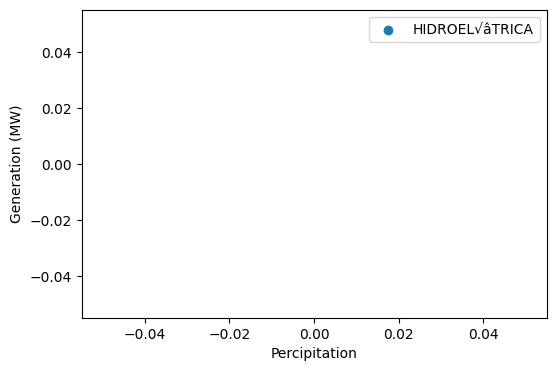

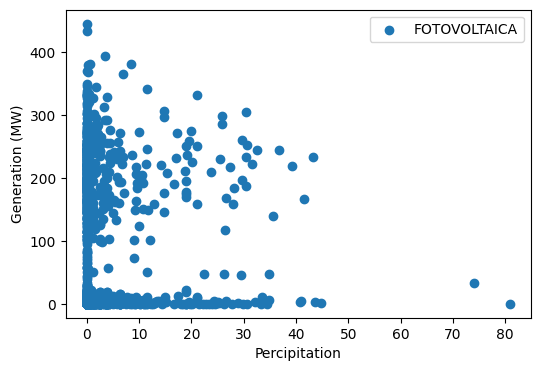

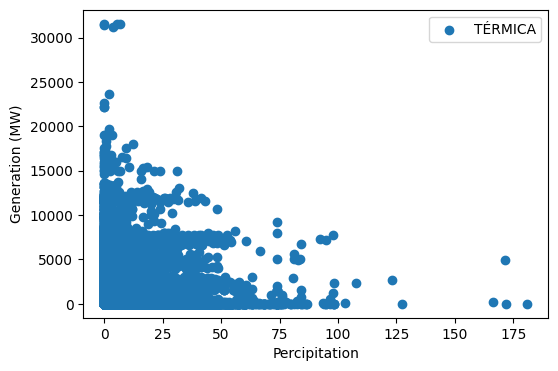

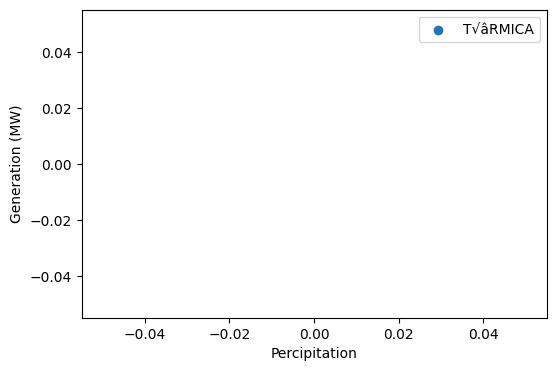

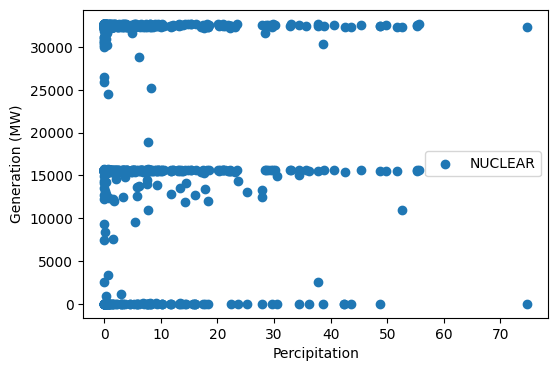

In [23]:
plant_types=df["plant_type"].dropna().unique()
corr_feats = ["gen_val(MW)", "ETo", "RH", "Rs", "Tmax", "Tmin", "pr", "u2"]
for typ in plant_types:
    subset = df[df['plant_type'] == typ]

    corr = subset[corr_feats].corr()
    print(f"Correlation for Type: {typ}: \n{corr.round(3)}")
    plt.figure(figsize=(6,4))
    plt.scatter(subset["pr"], subset["gen_val(MW)"], label=f"{typ}")
    plt.legend()
    plt.xlabel("Percipitation")
    plt.ylabel("Generation (MW)")

In [ ]:
weather_feats = ['ETo','RH','Rs','Tmax','Tmin','pr','u2']
lagged_feats = []

for feat in weather_feats:
    lag_name = f'{feat}_lag1'
    df[lag_name] = df.groupby('ceg')[feat].shift(1)
    lagged_feats.append(lag_name)


In [ ]:
plant_types=df["plant_type"].dropna().unique()
corr_feats = ["gen_val(MW)", "ETo", "RH", "Rs", "Tmax", "Tmin", "pr", "u2"]
for typ in plant_types:
    subset = df[df['plant_type'] == typ]

In [9]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Define target and split date
target = "gen_val(MW)"
split_date = "2023-06-01"

# Sort by time
df = df.sort_values("date")

# Train/test split
train = df[df["date"] < split_date]
test = df[df["date"] >= split_date]

# Compute mean generation per plant (ceg)
plant_means = train.groupby("ceg")[target].mean().to_dict()

# Predict: for each ceg in test, use its training mean
test["pred_baseline_mean"] = test["ceg"].map(plant_means)

# Handle plants in test not seen in train
overall_mean = train[target].mean()
test["pred_baseline_mean"].fillna(overall_mean, inplace=True)

# Evaluate
mse = mean_squared_error(test[target], test["pred_baseline_mean"])
r2 = r2_score(test[target], test["pred_baseline_mean"])

print(f"Baseline per-plant mean model:")
print(f"  MSE: {mse:.4f}")
print(f"  R^2: {r2:.4f}")

# Optional: per plant_type summary
summary = (
    test.groupby("plant_type")
    .apply(lambda g: pd.Series({
        "MSE": mean_squared_error(g[target], g["pred_baseline_mean"]),
        "R2": r2_score(g[target], g["pred_baseline_mean"])
    }))
)
print("\nPer plant_type baseline performance:")
print(summary)


Baseline per-plant mean model:
  MSE: 39998158.7312
  R^2: 0.7512

Per plant_type baseline performance:
                        MSE          R2
plant_type                             
EOLIELÉTRICA   8.516125e+05   -9.873918
FOTOVOLTAICA   2.585425e+06 -184.895696
HIDROELÉTRICA  7.124553e+07    0.745636
NUCLEAR        1.001204e+08    0.317536
TÉRMICA        4.115902e+06    0.034114


/var/folders/_m/xsh_fzl95l56pxzs3m8qngw00000gn/T/ipykernel_934/2893834791.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["pred_baseline_mean"] = test["ceg"].map(plant_means)
/var/folders/_m/xsh_fzl95l56pxzs3m8qngw00000gn/T/ipykernel_934/2893834791.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on t

In [10]:
df.head()

,ceg,latitude_x,longitude_x,date,gen_val(MW),subsys_name,state_name,plant_opn_mode,plant_type,fuel_type,...,time,latitude_y,longitude_y,ETo,RH,Rs,Tmax,Tmin,pr,u2
146326,UHE.PH.MG.002699-9.01,-17.896153,-40.201824,2020-01-01,0.000,SUDESTE,MINAS GERAIS,TIPO I,HIDROELÉTRICA,Hidráulica,...,2020-01-01,-17.85,-40.25,5.732284,76.77165,26.961811,32.842342,19.862210,7.965331,1.712598
327927,UHE.PH.SP.003045-7.01,-20.033267,-48.221844,2020-01-01,3769.812,SUDESTE,MINAS GERAIS,TIPO I,HIDROELÉTRICA,Hidráulica,...,2020-01-01,-20.05,-48.25,4.964567,75.59055,21.777952,33.970306,21.058535,2.533799,1.240158
183487,UHE.PH.MT.030422-0.01,-10.984805,-55.766005,2020-01-01,2414.482,SUDESTE,MATO GROSSO,TIPO I,HIDROELÉTRICA,Hidráulica,...,2020-01-01,-10.95,-55.75,2.917323,88.58268,13.609448,28.578295,22.323221,5.589465,0.590551
181601,UHE.PH.MT.029597-3.01,-10.163333,-59.464167,2020-01-01,6070.620,SUDESTE,MATO GROSSO,TIPO I,HIDROELÉTRICA,Hidráulica,...,2020-01-01,-10.15,-59.45,3.224409,85.43307,14.866141,30.731682,22.989746,6.962798,0.472441
557215,UTE.PE.RN.028655-9.01,-58.706208,-35.293312,2020-01-01,0.000,NORDESTE,RIO GRANDE DO NORTE,TIPO I,TÉRMICA,Óleo Diesel,...,2020-01-01,-33.65,-53.25,2.968504,88.58268,14.866141,24.288614,21.314890,17.455061,3.661417


In [13]:
print(df.columns)

Index(['ceg', 'latitude_x', 'longitude_x', 'date', 'gen_val(MW)',
       'subsys_name', 'state_name', 'plant_opn_mode', 'plant_type',
       'fuel_type', 'ons_id', 'wx_lat', 'wx_lon', 'wx_distance_deg', 'time',
       'latitude_y', 'longitude_y', 'ETo', 'RH', 'Rs', 'Tmax', 'Tmin', 'pr',
       'u2'],
      dtype='object')
